Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.0682 - loss: 3.1983 - val_accuracy: 0.3818 - val_loss: 2.2668
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5676 - loss: 1.5683 - val_accuracy: 0.7801 - val_loss: 0.7593
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8617 - loss: 0.4994 - val_accuracy: 0.9218 - val_loss: 0.3028
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9392 - loss: 0.2361 - val_accuracy: 0.9444 - val_loss: 0.2166
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9619 - loss: 0.1550 - val_accuracy: 0.9491 - val_loss: 0.1766
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9694 - loss: 0.1211 - val_accuracy: 0.9664 - val_loss: 0.1238
Epoch 7/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9859 - loss: 0.0642 - val_accuracy: 0.9585 - val_loss: 0.1514
Epoch 8/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9852 - loss: 0.0595 - val_accu

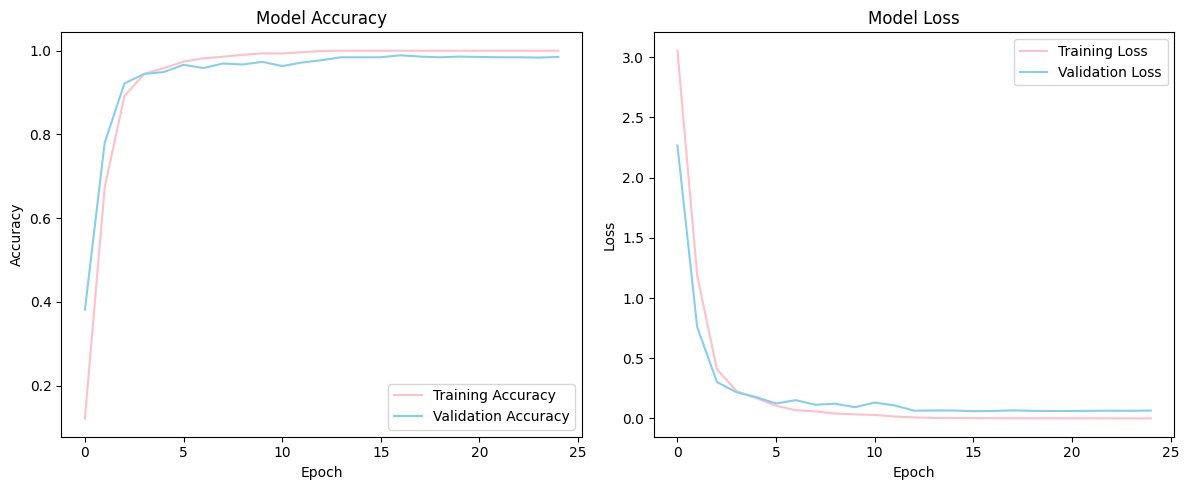

In [2]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Function to load and preprocess images from multiple subject folders
def load_images_from_folders(main_folder, img_size=(32, 32)):
    images = []
    labels = []
    subject_id = 0

    # Iterate through the 25 folders for subjects
    for folder_name in os.listdir(main_folder):
        folder_path = os.path.join(main_folder, folder_name)
        if os.path.isdir(folder_path):
            for filename in os.listdir(folder_path):
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img_resized = cv2.resize(img, img_size)
                    images.append(img_resized.flatten())
                    labels.append(subject_id)  # Label by subject
            subject_id += 1

    return np.array(images), np.array(labels)

# Function to load selfie images
def load_selfie_images(selfie_folder, img_size=(32, 32)):
    images = []
    labels = []
    for filename in os.listdir(selfie_folder):
        img_path = os.path.join(selfie_folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_resized = cv2.resize(img, img_size)
            images.append(img_resized.flatten())
            labels.append(25)  # Label all selfies as class 25
    return np.array(images), np.array(labels)

# Load images from the 25 subject folders
X_cmu, y_cmu = load_images_from_folders('C:/Users/Administrator/Desktop/EE5907/Qi Ninghan/data')

# Load selfie images
X_selfie, y_selfie = load_selfie_images('C:/Users/Administrator/Desktop/EE5907/Qi Ninghan/selfie')

# Split 25 subjects' dataset into training (70%) and testing (30%)
X_train_cmu, X_test_cmu, y_train_cmu, y_test_cmu = train_test_split(
    X_cmu, y_cmu, test_size=0.3, random_state=42
)

# Split selfie images with stratified sampling (to ensure some selfies are in the test set)
X_train_selfie, X_test_selfie, y_train_selfie, y_test_selfie = train_test_split(
    X_selfie, y_selfie, test_size=0.3, random_state=42
)

# Combine subjects' and selfies' training sets and testing sets separately
X_train = np.vstack((X_train_cmu, X_train_selfie))
y_train = np.hstack((y_train_cmu, y_train_selfie))

X_test = np.vstack((X_test_cmu, X_test_selfie))
y_test = np.hstack((y_test_cmu, y_test_selfie))

# Randomly sample 500 images from the CMU PIE training set and my own photos
N_selfie_train = X_train_selfie.shape[0]
N_sample_cmu = 500 - N_selfie_train

indices_cmu = np.random.choice(X_train_cmu.shape[0], N_sample_cmu, replace=False)
X_sample_cmu = X_train_cmu[indices_cmu]
y_sample_cmu = y_train_cmu[indices_cmu]

X_sample_selfie = X_train_selfie
y_sample_selfie = y_train_selfie

X_sample = np.vstack((X_sample_cmu, X_sample_selfie))
y_sample = np.hstack((y_sample_cmu, y_sample_selfie))

X_train_cnn = X_train.reshape(-1, 32, 32, 1)
X_test_cnn = X_test.reshape(-1, 32, 32, 1)

# Normalize pixel values to [0,1]
X_train_cnn = X_train_cnn.astype('float32') / 255.0
X_test_cnn = X_test_cnn.astype('float32') / 255.0

# Convert labels to categorical
num_classes = 26  # 25 CMU PIE subjects + 1 for own photos
y_train_cnn = to_categorical(y_train, num_classes)
y_test_cnn = to_categorical(y_test, num_classes)

# Build the CNN model
model = Sequential()

# Input layer
model.add(Input(shape=(32, 32, 1)))

# First convolutional layer
model.add(Conv2D(filters=20, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))

# Second convolutional layer
model.add(Conv2D(filters=50, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))

# Flatten the output
model.add(Flatten())

# Fully connected layer
model.add(Dense(500))
model.add(Activation('relu'))

# Output layer
model.add(Dense(num_classes))
model.add(Activation('softmax'))

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_cnn, y_train_cnn, epochs=25, batch_size=30, validation_data=(X_test_cnn, y_test_cnn))

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f'Test Accuracy: {test_accuracy:.4f}')

# Compute accuracy for CMU PIE test images
is_selfie_test = (y_test == 25)
cmu_test_indices = np.where(~is_selfie_test)[0]
selfie_test_indices = np.where(is_selfie_test)[0]

cmu_test_accuracy = model.evaluate(X_test_cnn[cmu_test_indices], y_test_cnn[cmu_test_indices], verbose=0)[1]
selfie_test_accuracy = model.evaluate(X_test_cnn[selfie_test_indices], y_test_cnn[selfie_test_indices], verbose=0)[1]

print(f'CMU PIE Test Accuracy: {cmu_test_accuracy:.4f}')
print(f'Own Photos Test Accuracy: {selfie_test_accuracy:.4f}')

# Plot accuracy
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='pink', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='skyblue', label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='pink', label='Training Loss')
plt.plot(history.history['val_loss'], color='skyblue', label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
